In [ ]:
# pyenv activate nitrates

In [1]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os

## Boyas UPCT

In [ ]:
# CCF - con ADF antes para ver si hay stationarity, si no la hay, descartar este test
# Two-Sample por pares de Kolmogorov Smirnov
# Correlación de Spearman? Si no se cumplen las condiciones de linearity, normality y homoscedasticity

In [8]:
path = "boyaUPCT/extractedData/"
buoy_id = "CTD4"

In [18]:
archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
dataframes = {}

# Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
for archivo in archivos_csv:
    nombre_variable = os.path.splitext(archivo)[0]
    ruta_completa = os.path.join(path, buoy_id, archivo)
    dataframes[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

In [23]:
dataframes.keys()

dict_keys(['CTD4_Oxigeno', 'CTD4_Salinidad', 'CTD4_PE', 'CTD4_Clorofila', 'CTD4_Temperatura', 'CTD4_Turbidez', 'CTD4_CDOM', 'CTD4_Transparency'])

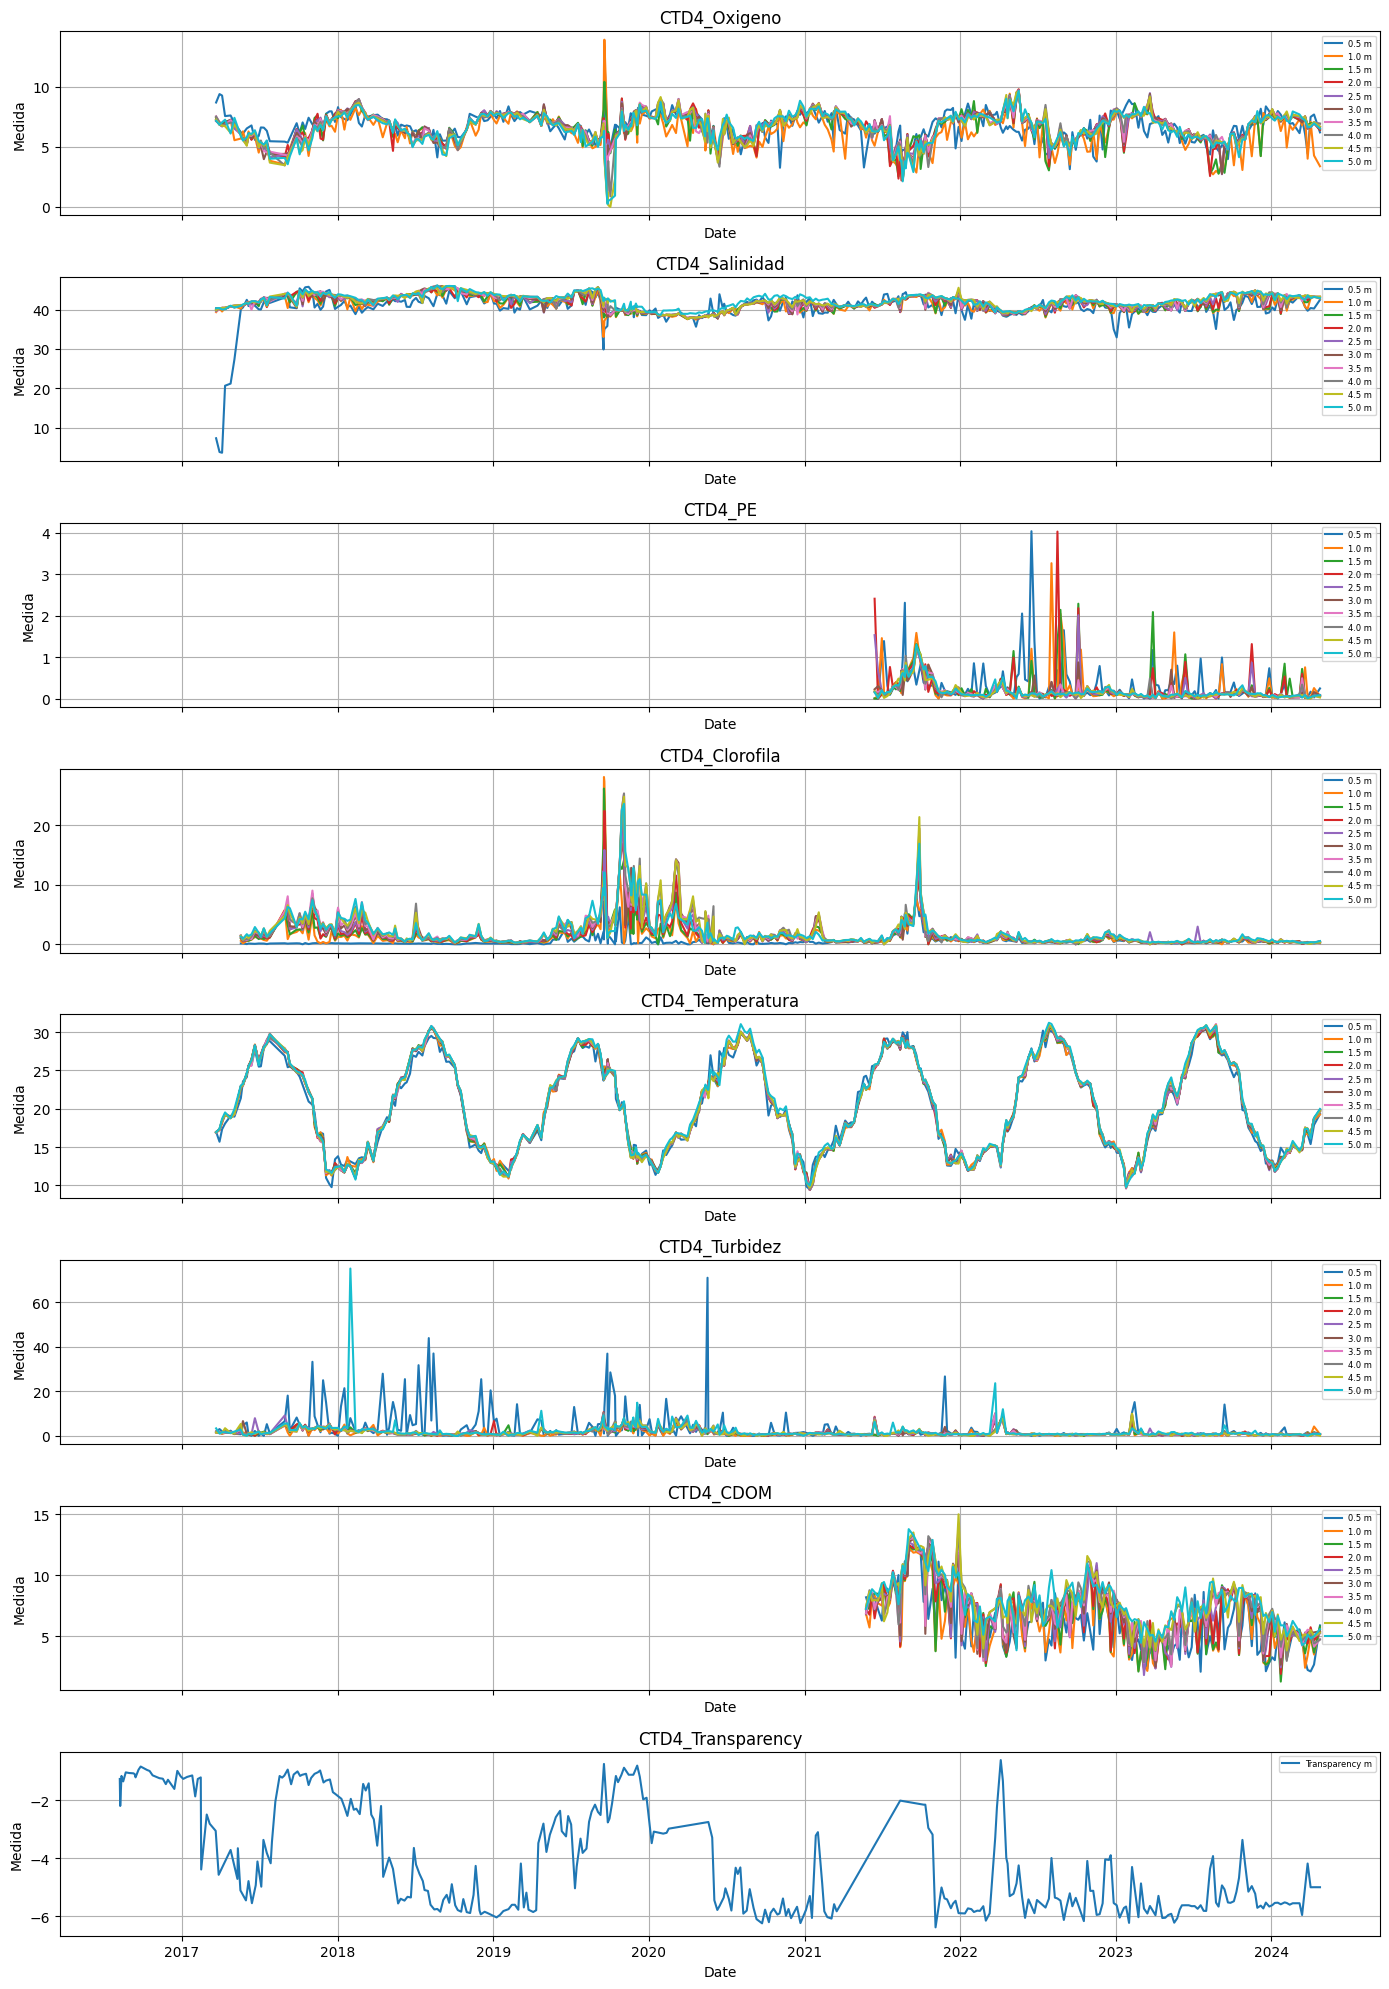

In [24]:
fig, ax = plt.subplots(figsize = (14,len(archivos_csv)*2.5), nrows=len(archivos_csv), ncols=1, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes.items()):
    # Convertir la columna 'Fecha' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    # Graficar cada columna de profundidad
    for columna in df.columns:
        if columna != 'Date':
            ax[i].plot(df['Date'], df[columna], label=f'{columna} m')

    # Configurar el subplot
    ax[i].set_title(nombre)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Medida')
    ax[i].legend(loc='best', fontsize=6)
    ax[i].grid(True)

fig.tight_layout()

Además de dejar una única medida, si se puede, de cada parámetro, guardar también la desviación estándar

#### Planteamiento - ¿Qué queremos hacer con cada paso del procesado?
- Ver si para cada parámetro de cada boya (Oxígeno, Temperatura, etc) es posible quedarnos con una medida representativa de todas las profundidades (+ su desviación estándar)
    - Comprobar normalidad y homogeneidad de varianzas de las series temporales.
    - Comprobar stationarity con ADF
    - Aplicar los tests de series temporales correspondientes: tipo ANOVA para analizar la igualdad de medias o tipo Engle-Granger si las series son no estacionarias
    - Análisis espectral para ver si están compuestas por las mismas frecuencias y análisis de correlación (directa, sin lags, tipo Pearson o Spearman)
- Ver cómo de relacionados están los caudales + relación con nivel y lluvia
    - Cross-correlation con lags y correlación directa
    - Análisis espectral
    - Para hacer este análisis representar un scatter plot de caudal SAIH vs caudal CMM y similares
- Pensar en cómo se puede reconstruir la serie de nitratos con las medidas que hay del SAIH
    - Encontrar alguna (s) variable que guarde algún tipo de correlación con los nitratos